In [1]:
import polars as pl

# Book dataset

In [2]:
books_df = pl.scan_ndjson("../raw-data/goodreads_books_fantasy_paranormal.json")

In [3]:
books_df = books_df.with_columns(
    pl.col("text_reviews_count").cast(pl.Int32, strict=False),
    pl.col("average_rating").cast(pl.Float32, strict=False),
    pl.col("num_pages").cast(pl.Int32, strict=False),
    pl.col("publication_day").cast(pl.Int8, strict=False),
    pl.col("publication_month").cast(pl.Int8, strict=False),
    pl.col("publication_year").cast(pl.Int32, strict=False),
    pl.col("book_id").cast(pl.Int64, strict=False),
    pl.col("ratings_count").cast(pl.Int32, strict=False),
    pl.col("work_id").cast(pl.Int64, strict=False)
)

In [4]:
books_df.count().show()

isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,176344,160499,258585,176444,258585,196074,258585,258585,258585,258585,258585,258585,258585


In [5]:
books_df = books_df.filter(pl.col('ratings_count') > 10)
books_df.count().show()

isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,145161,129382,204482,141498,204482,155363,204482,204482,204482,204482,204482,204482,204482


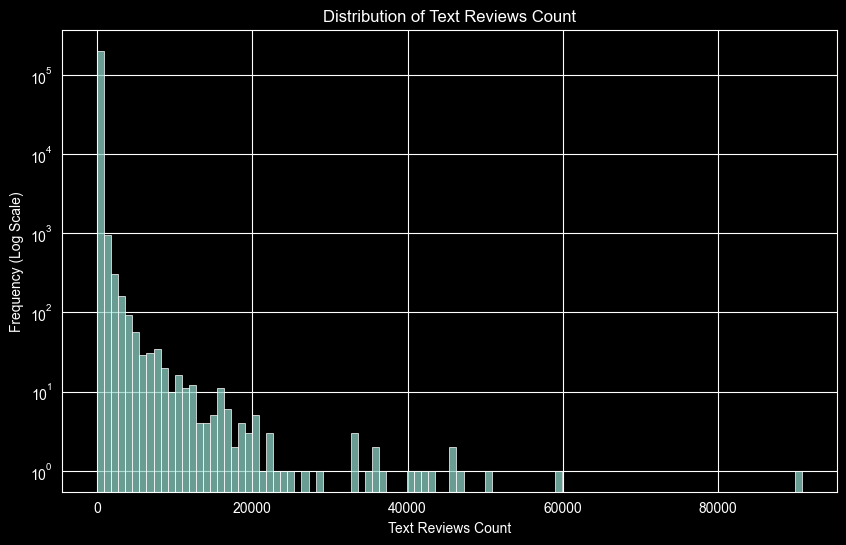

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the column for visualization
text_reviews = books_df.select("text_reviews_count").drop_nulls().collect().to_pandas()

plt.figure(figsize=(10, 6))
sns.histplot(data=text_reviews, x="text_reviews_count", bins=100)
plt.yscale("log")
plt.title("Distribution of Text Reviews Count")
plt.xlabel("Text Reviews Count")
plt.ylabel("Frequency (Log Scale)")
plt.show()

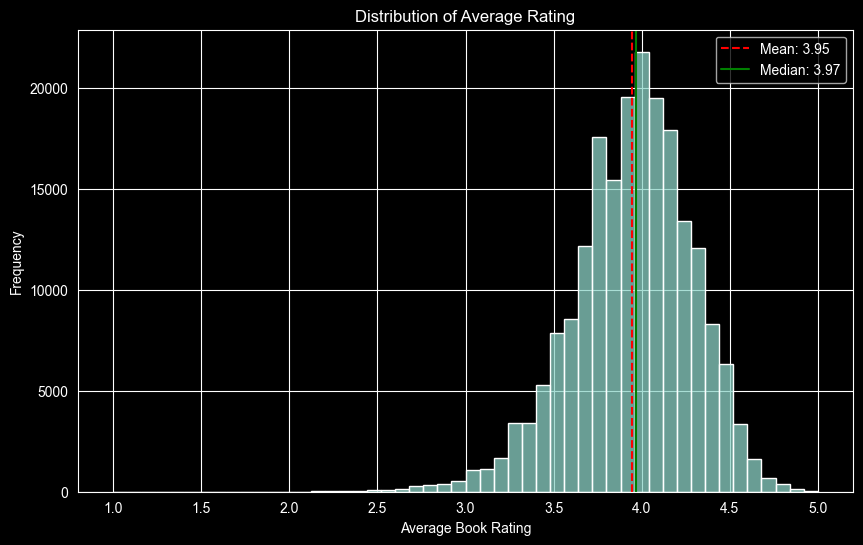

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the column for visualization
text_reviews = books_df.select("average_rating").drop_nulls().collect().to_pandas()

mean_rating = text_reviews["average_rating"].mean()
median_rating = text_reviews["average_rating"].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=text_reviews, x="average_rating", bins=50)
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='-', label=f'Median: {median_rating:.2f}')
# plt.yscale("log")
plt.title("Distribution of Average Rating")
plt.xlabel("Average Book Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Interactions dataset

In [8]:
interactions_df = pl.scan_ndjson("../raw-data/goodreads_interactions_fantasy_paranormal.json")

In [9]:
interactions_df.head().show()

user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""19161852""","""4443cb6883624c3772625ef5b7b4e1…",false,0,"""""","""Fri Sep 08 10:44:24 -0700 2017""","""Fri Sep 08 10:44:24 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""32075825""","""11ffeb4204d7421f716a8f91c190ef…",false,0,"""""","""Wed May 31 06:41:50 -0700 2017""","""Wed May 31 06:41:51 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""43615""","""07ab7d654e3c84769e5eb8e5cabd5e…",false,0,"""""","""Mon Apr 03 13:27:29 -0700 2017""","""Mon Apr 03 13:27:30 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""26721984""","""90b82c8d8e8a514b5fd1e4568075e0…",false,0,"""""","""Wed Mar 29 00:28:30 -0700 2017""","""Wed Mar 29 00:28:31 -0700 2017""","""""",""""""


In [17]:
interactions_df = interactions_df.filter(pl.col('rating') > 0 & pl.col('is_read') == True)
interactions_df.collect().show()

user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""","""3759ba2b18dd09eb5e844a116f0ce0…",true,3,"""""","""Mon Jul 25 14:29:33 -0700 2016""","""Tue Dec 13 11:00:02 -0800 2016""","""Sat Aug 20 00:00:00 -0700 2016""","""Wed Aug 17 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""186074""","""1d12addadc0c737dcd29c362c936a2…",true,5,"""""","""Tue Jul 12 19:21:10 -0700 2016""","""Wed Mar 22 11:47:46 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""15839976""","""c7baa53f6f7d554ed9c3859f0d400d…",true,5,"""""","""Tue May 10 11:34:44 -0700 2016""","""Wed Mar 22 11:47:45 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",true,5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014"""


Investigate the number of user reviews.

The Goodreads dataset was collected in 2017 (per authors), while Goodreads was created in December 2006 (per Wikipedia). Given some rounding erros, that makes around 4000 days. It would make sense to remove some clearly botted accounts that read more than 1 book in a few days.

In [19]:
interactions_per_user = interactions_df.group_by("user_id").agg(pl.col("book_id").count().alias("interaction_count"))

metrics = interactions_per_user.select([
    pl.col("user_id").count().alias("unique_users"),
    pl.col("interaction_count").mean().alias("avg_interactions"),
    pl.col("interaction_count").median().alias("median_interactions"),
]).collect()

print(f"Number of unique users: {metrics.get_column('unique_users')[0]}")
print(f"Average number of interactions per user: {metrics.get_column('avg_interactions')[0]:.2f}")
print(f"Median number of interactions per user: {metrics.get_column('median_interactions')[0]:.2f}")



Number of unique users: 656621
Average number of interactions per user: 39.89
Median number of interactions per user: 13.00


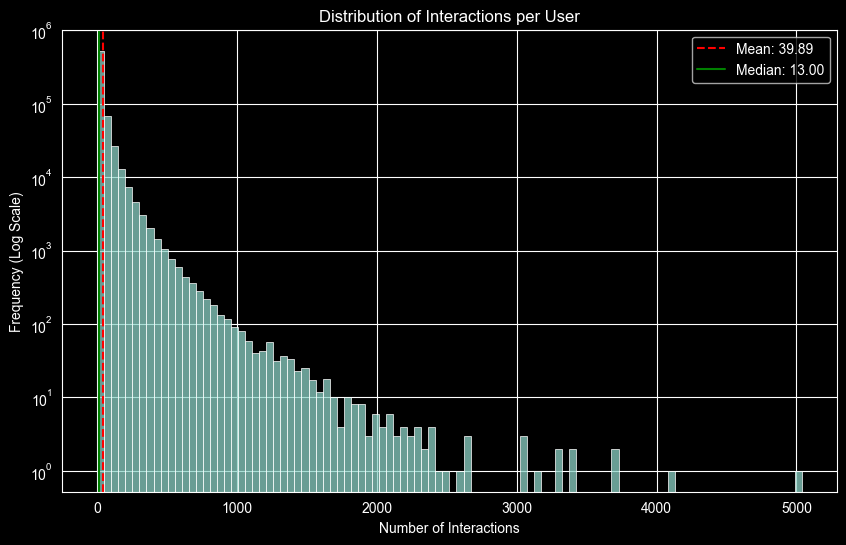

In [22]:
interactions_counts_pd = interactions_per_user.select("interaction_count").collect().to_pandas()


plt.figure(figsize=(10, 6))
sns.histplot(data=interactions_counts_pd, x="interaction_count", bins=100)
plt.yscale("log")
plt.title("Distribution of Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency (Log Scale)")
plt.legend()
plt.show()


Min: 1, Max: 5038
Q1: 4.0, Median: 13.0, Q3: 39.0
IQR: 35.0
Lower bound: -48.5
Upper bound: 91.5
Number of outlier users: 71255


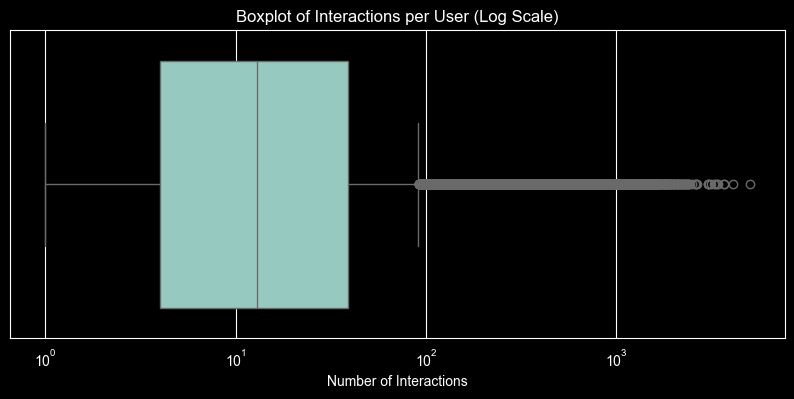

In [16]:
# Outlier analysis on interaction counts using the IQR method
quantiles = interactions_per_user.select([
    pl.col("interaction_count").quantile(0.25).alias("q1"),
    pl.col("interaction_count").quantile(0.50).alias("median"),
    pl.col("interaction_count").quantile(0.75).alias("q3"),
    pl.col("interaction_count").max().alias("max"),
    pl.col("interaction_count").min().alias("min")
]).collect()

q1 = quantiles.get_column("q1")[0]
median = quantiles.get_column("median")[0]
q3 = quantiles.get_column("q3")[0]
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Min: {quantiles.get_column('min')[0]}, Max: {quantiles.get_column('max')[0]}")
print(f"Q1: {q1}, Median: {median}, Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Count outliers
outliers = interactions_per_user.filter(
    (pl.col("interaction_count") < lower_bound) |
    (pl.col("interaction_count") > upper_bound)
).select(pl.len()).collect()

outlier_count = outliers.get_column('count')[0] if 'count' in outliers.columns else outliers.item()
print(f"Number of outlier users: {outlier_count}")

# Visualize the outliers using a boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=interactions_counts_pd["interaction_count"])
plt.xscale("log")
plt.title("Boxplot of Interactions per User (Log Scale)")
plt.xlabel("Number of Interactions")
plt.show()


Average rating across all users: 4.08


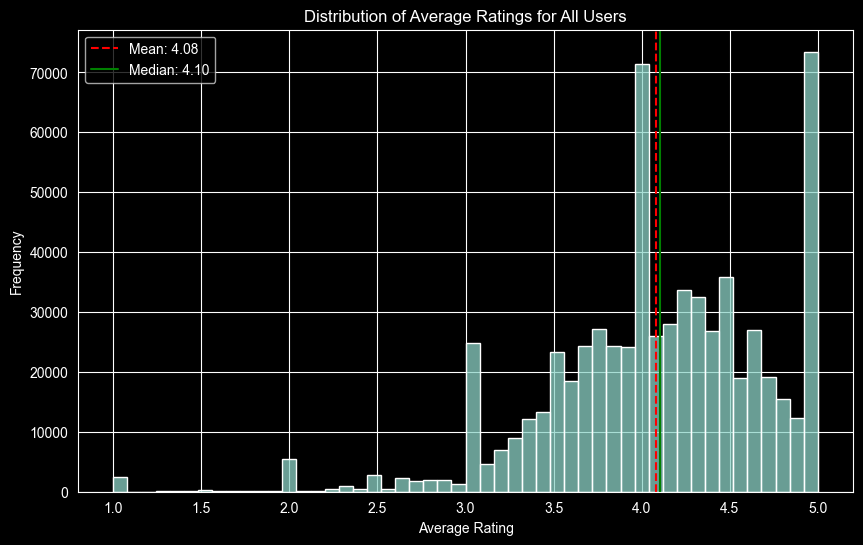

In [32]:
# Calculate the average rating for all users
all_users_avg_ratings = interactions_df.group_by("user_id").agg(
    pl.col("rating").mean().alias("avg_rating")
).collect().to_pandas()

mean_all_rating = all_users_avg_ratings["avg_rating"].mean()
median_all_rating = all_users_avg_ratings["avg_rating"].median()

print(f"Average rating across all users: {mean_all_rating:.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(data=all_users_avg_ratings, x="avg_rating", bins=50)
plt.axvline(mean_all_rating, color='red', linestyle='--', label=f'Mean: {mean_all_rating:.2f}')
plt.axvline(median_all_rating, color='green', linestyle='-', label=f'Median: {median_all_rating:.2f}')
plt.title("Distribution of Average Ratings for All Users")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [28]:
# Calculate the average rating of readers with more than 1000 reviews
power_users = interactions_per_user.filter(pl.col("interaction_count") > 1000).select("user_id")

power_users_interactions = interactions_df.join(power_users, on="user_id", how="inner")
avg_rating = power_users_interactions.select(pl.col("rating").mean()).collect().item()

print(f"Average rating of readers with > 1000 reviews: {avg_rating:.2f}")


Average rating of readers with > 1000 reviews: 3.82


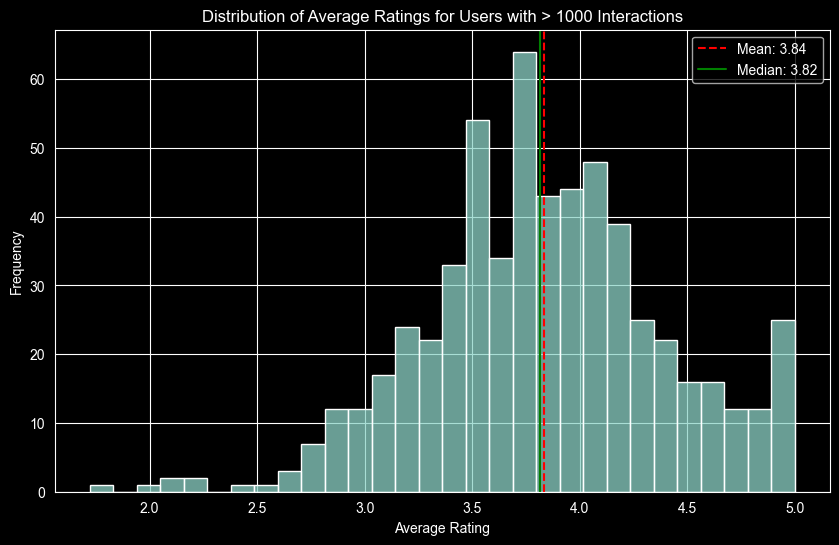

In [29]:
power_users_avg_ratings = power_users_interactions.group_by("user_id").agg(
    pl.col("rating").mean().alias("avg_rating")
).collect().to_pandas()

mean_power_rating = power_users_avg_ratings["avg_rating"].mean()
median_power_rating = power_users_avg_ratings["avg_rating"].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=power_users_avg_ratings, x="avg_rating", bins=30)
plt.axvline(mean_power_rating, color='red', linestyle='--', label=f'Mean: {mean_power_rating:.2f}')
plt.axvline(median_power_rating, color='green', linestyle='-', label=f'Median: {median_power_rating:.2f}')
plt.title("Distribution of Average Ratings for Users with > 1000 Interactions")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Average rating of readers with <= 1000 reviews: 4.08


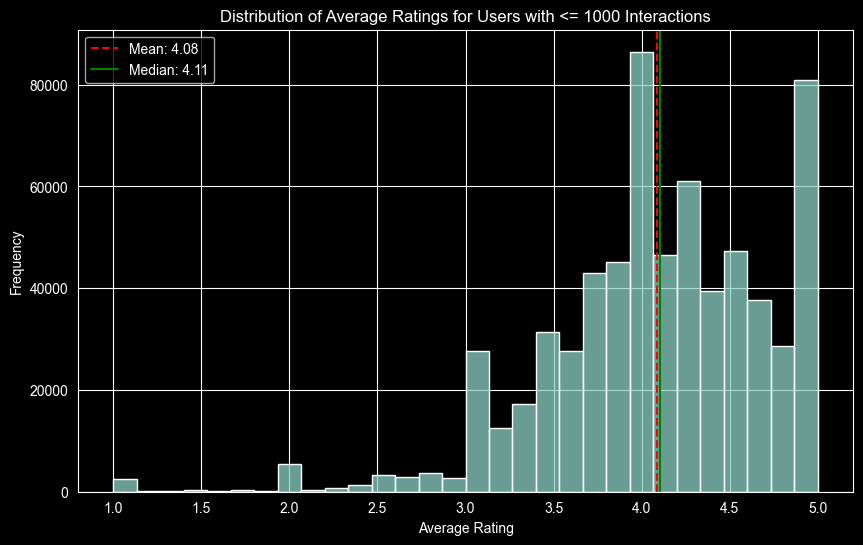

In [30]:
# Calculate the average ratings of readers with <= 1000 reviews (normal users)
normal_users = interactions_per_user.filter(pl.col("interaction_count") <= 1000).select("user_id")

normal_users_interactions = interactions_df.join(normal_users, on="user_id", how="inner")
normal_users_avg_ratings = normal_users_interactions.group_by("user_id").agg(
    pl.col("rating").mean().alias("avg_rating")
).collect().to_pandas()

mean_normal_rating = normal_users_avg_ratings["avg_rating"].mean()
median_normal_rating = normal_users_avg_ratings["avg_rating"].median()

print(f"Average rating of readers with <= 1000 reviews: {mean_normal_rating:.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(data=normal_users_avg_ratings, x="avg_rating", bins=30)
plt.axvline(mean_normal_rating, color='red', linestyle='--', label=f'Mean: {mean_normal_rating:.2f}')
plt.axvline(median_normal_rating, color='green', linestyle='-', label=f'Median: {median_normal_rating:.2f}')
plt.title("Distribution of Average Ratings for Users with <= 1000 Interactions")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Reviews dataset

In [13]:
reviews_df = pl.scan_ndjson("../raw-data/goodreads_reviews_fantasy_paranormal.json")

In [14]:
reviews_df.head().show()

user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
str,str,str,i64,str,str,str,str,str,i64,i64
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017""",28,1
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014""",5,1
"""8842281e1d1347389f2ab93d60773d…","""17315048""","""885c772fb033b041f42d57cef5be0a…",5,"""Mark Watney is a steely-eyed m…","""Sat Apr 05 09:30:53 -0700 2014""","""Wed Mar 22 11:33:10 -0700 2017""","""Mon Aug 25 00:00:00 -0700 2014""","""Sat Aug 16 00:00:00 -0700 2014""",25,5
"""8842281e1d1347389f2ab93d60773d…","""13453029""","""46a6e1a14e8afc82d221fec0a2bd3d…",4,"""A fun fast paced book that suc…","""Tue Dec 04 11:12:22 -0800 2012""","""Sat Jul 26 11:43:28 -0700 2014""","""Tue Jul 08 00:00:00 -0700 2014""","""Wed Jul 02 00:00:00 -0700 2014""",5,1
"""8842281e1d1347389f2ab93d60773d…","""13239822""","""a582bfa8efd69d453a5a21a678046b…",3,"""This book has a great premise,…","""Mon Jul 02 16:04:16 -0700 2012""","""Wed Mar 22 11:32:20 -0700 2017""","""Wed Aug 15 00:00:00 -0700 2012""","""Sun Aug 12 00:00:00 -0700 2012""",7,0
